# Diamonds

The diamonds dataset is a well known dataset. It's one of the basic examplesets you get in the R-programming suite, but you can also [download](https://www.kaggle.com/datasets/shivam2503/diamonds) it as a csv. We've done that for you and stored it in the files folder.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df=pd.read_csv("files/diamonds.csv", index_col=0)
df.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Also describe the dataset, so you have an idea of the data.

In [7]:
import pandas as pd

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

print("DIAMONDS DATASET DESCRIPTION")
print("=" * 60)

# Basic information
print(f"\n📊 SIZE: {df.shape[0]:,} rows and {df.shape[1]} columns")
print(f"\n📋 COLUMNS: {list(df.columns)}")

# Data types
print(f"\n📌 DATA TYPES:")
print(df.dtypes)

# First few rows
print(f"\n🔍 FIRST 5 ROWS:")
print(df.head())

# Statistical summary for numerical columns
print(f"\n📈 NUMERICAL COLUMNS SUMMARY:")
print(df.describe().round(2))

# Categorical columns info
print(f"\n📊 CATEGORICAL COLUMNS SUMMARY:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Categories: {df[col].unique()[:5]}...")
    print(f"  Most common: {df[col].value_counts().index[0]} ({df[col].value_counts().values[0]:,})")

# Missing values
print(f"\n❓ MISSING VALUES:")
print(df.isnull().sum())

DIAMONDS DATASET DESCRIPTION

📊 SIZE: 53,940 rows and 10 columns

📋 COLUMNS: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

📌 DATA TYPES:
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

🔍 FIRST 5 ROWS:
   carat      cut color clarity  depth  table  price     x     y     z
1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75

📈 NUMERICAL COLUMNS SUMMARY:
          carat     depth     table     price         x         y         z
count  53940.00  53940.00  53940.00  53940.00  53940.00  53940.00  53940.00


Create a bar-chart showing how many diamonds there are of every cut. You can use matplotlib and grouping, but easier would be to use seaborn's countplot.

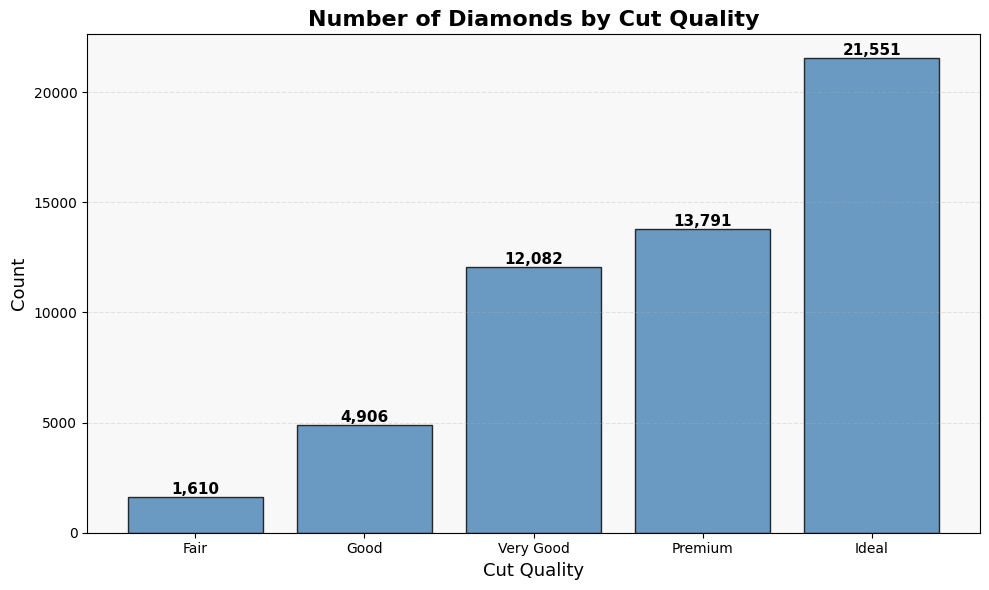


📊 COUNT OF DIAMONDS BY CUT:
----------------------------------------
Fair        :      1,610 diamonds
Good        :      4,906 diamonds
Very Good   :     12,082 diamonds
Premium     :     13,791 diamonds
Ideal       :     21,551 diamonds
----------------------------------------
Total       :     53,940 diamonds


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Define correct order for cut
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']

# Calculate counts in correct order
cut_counts = df['cut'].value_counts().reindex(cut_order)

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(cut_counts.index, cut_counts.values, color='steelblue', edgecolor='black', alpha=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize
plt.title('Number of Diamonds by Cut Quality', fontsize=16, fontweight='bold')
plt.xlabel('Cut Quality', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=0)

# Add a background color
plt.gca().set_facecolor('#f8f8f8')

plt.tight_layout()
plt.show()

# Print the actual counts
print("\n📊 COUNT OF DIAMONDS BY CUT:")
print("-" * 40)
for cut in cut_order:
    print(f"{cut:12}: {cut_counts[cut]:>10,} diamonds")
print("-" * 40)
print(f"{'Total':12}: {cut_counts.sum():>10,} diamonds")

The bottom line of the previous graph is:

![](files/2022-08-30-13-39-46.png)

Which isn't good because there is an order in the cut of diamonds. It's:

<code>['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']</code>


Turn the "cut"-column into an ordered categorical column. You can use the list in this markdown-cell. We have a second one of those lists:

<code>['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']</code>

This is the "clarity", another ordered categorical.

CUT COLUMN:
Categories: ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
Ordered: True
First 10 values: ['Ideal', 'Premium', 'Good', 'Premium', 'Good', 'Very Good', 'Very Good', 'Very Good', 'Fair', 'Very Good']

CLARITY COLUMN:
Categories: ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
Ordered: True
First 10 values: ['SI2', 'SI1', 'VS1', 'VS2', 'SI2', 'VVS2', 'VVS1', 'SI1', 'VS2', 'VS1']



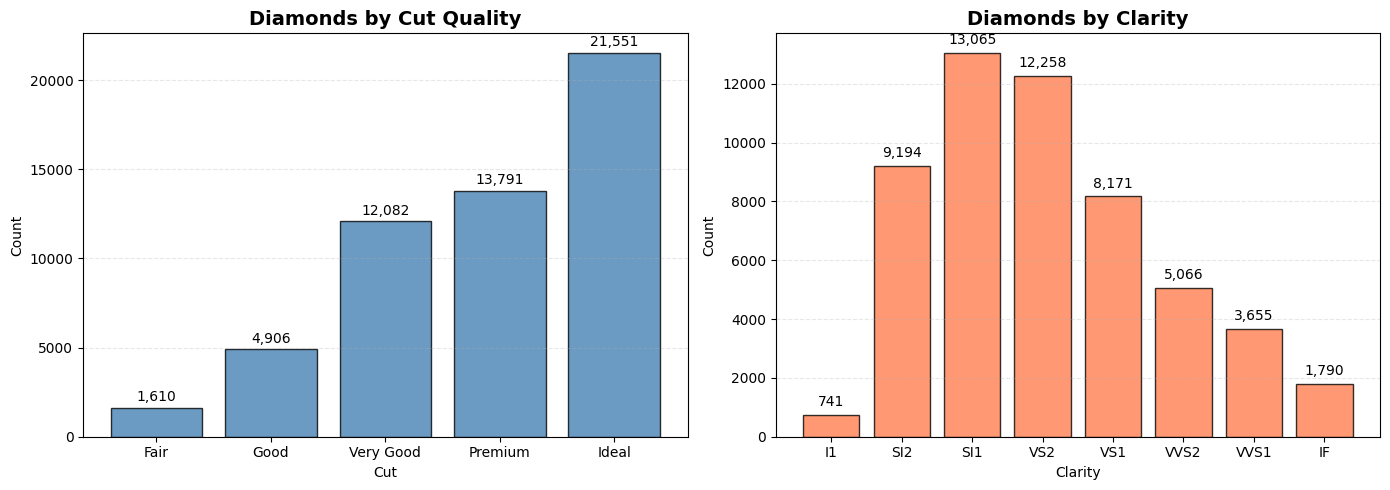


📊 CUT VALUE COUNTS (in correct order):
--------------------------------------------------
Fair        :      1,610
Good        :      4,906
Very Good   :     12,082
Premium     :     13,791
Ideal       :     21,551

📊 CLARITY VALUE COUNTS (in correct order):
--------------------------------------------------
I1    :        741
SI2   :      9,194
SI1   :     13,065
VS2   :     12,258
VS1   :      8,171
VVS2  :      5,066
VVS1  :      3,655
IF    :      1,790


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Define the correct order for cut
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']

# Convert cut to ordered categorical
df['cut'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True)

# Define the correct order for clarity (from worst to best)
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# Convert clarity to ordered categorical
df['clarity'] = pd.Categorical(df['clarity'], categories=clarity_order, ordered=True)

# Verify the changes
print("=" * 60)
print("CUT COLUMN:")
print("=" * 60)
print(f"Categories: {df['cut'].cat.categories.tolist()}")
print(f"Ordered: {df['cut'].cat.ordered}")
print(f"First 10 values: {df['cut'].head(10).tolist()}")
print()

print("=" * 60)
print("CLARITY COLUMN:")
print("=" * 60)
print(f"Categories: {df['clarity'].cat.categories.tolist()}")
print(f"Ordered: {df['clarity'].cat.ordered}")
print(f"First 10 values: {df['clarity'].head(10).tolist()}")
print()

# Now plot with correct order using matplotlib
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cut counts in correct order
cut_counts = df['cut'].value_counts().sort_index()
axes[0].bar(cut_counts.index, cut_counts.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Diamonds by Cut Quality', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cut')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, v in enumerate(cut_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', va='bottom', fontsize=10)

# Plot 2: Clarity counts in correct order
clarity_counts = df['clarity'].value_counts().sort_index()
axes[1].bar(clarity_counts.index, clarity_counts.values, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title('Diamonds by Clarity', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Clarity')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, v in enumerate(clarity_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print the actual counts
print("\n📊 CUT VALUE COUNTS (in correct order):")
print("-" * 50)
for cut in cut_order:
    print(f"{cut:12}: {cut_counts[cut]:>10,}")

print("\n📊 CLARITY VALUE COUNTS (in correct order):")
print("-" * 50)
for clarity in clarity_order:
    print(f"{clarity:6}: {clarity_counts[clarity]:>10,}")

Now recreate the previous graph. The labels on the axis should be sorted correctly now.

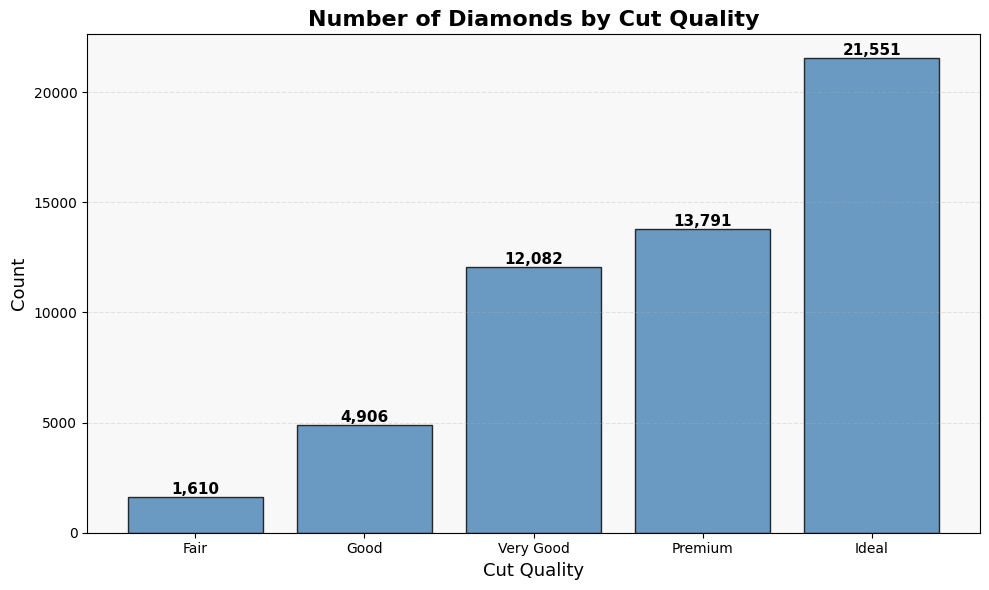


📊 DIAMONDS BY CUT QUALITY:
----------------------------------------
Fair        :      1,610 diamonds
Good        :      4,906 diamonds
Very Good   :     12,082 diamonds
Premium     :     13,791 diamonds
Ideal       :     21,551 diamonds


In [11]:

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Define the correct order for cut
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']

# Convert cut to ordered categorical
df['cut'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True)

# Calculate counts in correct order
cut_counts = df['cut'].value_counts().sort_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(cut_counts.index, cut_counts.values, color='steelblue', edgecolor='black', alpha=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize
plt.title('Number of Diamonds by Cut Quality', fontsize=16, fontweight='bold')
plt.xlabel('Cut Quality', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f8f8')

# Ensure x-axis labels are in correct order
plt.xticks(range(len(cut_order)), cut_order)

plt.tight_layout()
plt.show()

# Print the counts
print("\n📊 DIAMONDS BY CUT QUALITY:")
print("-" * 40)
for cut in cut_order:
    print(f"{cut:12}: {cut_counts[cut]:>10,} diamonds")

Show a distribution of diamonds by size (aka carat) using a histogram.

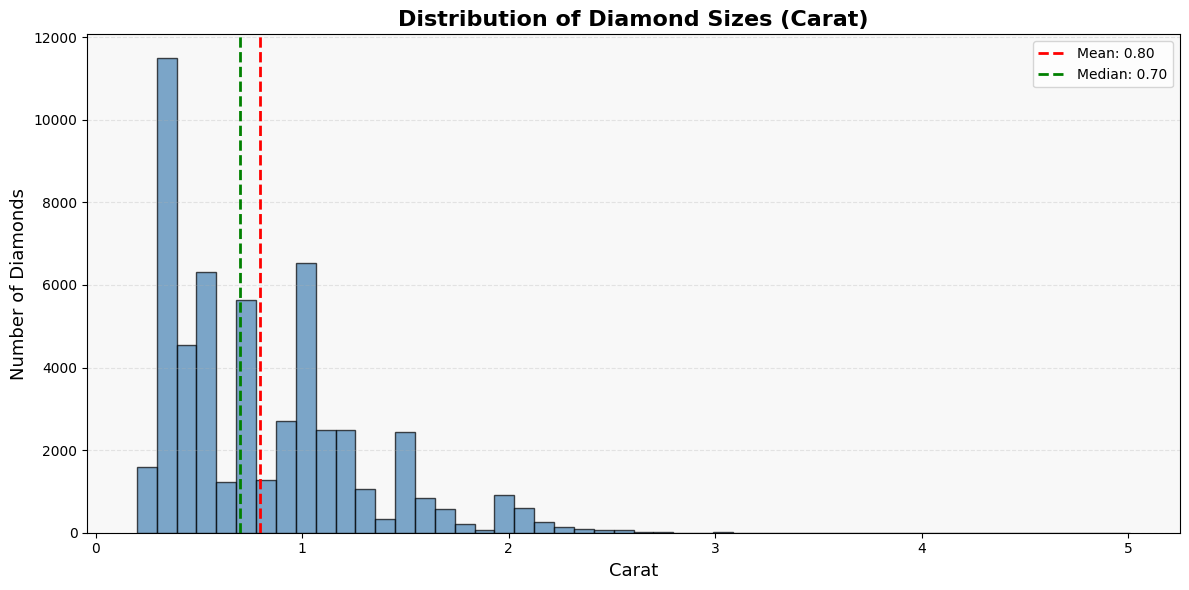

DIAMOND CARAT STATISTICS
Mean carat:      0.798
Median carat:    0.700
Minimum carat:   0.200
Maximum carat:   5.010
Standard dev:    0.474
Total diamonds:  53,940


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Create histogram
plt.figure(figsize=(12, 6))

# Plot histogram with 50 bins
counts, bins, patches = plt.hist(df['carat'], bins=50, color='steelblue', 
                                  edgecolor='black', alpha=0.7)

# Add labels and title
plt.title('Distribution of Diamond Sizes (Carat)', fontsize=16, fontweight='bold')
plt.xlabel('Carat', fontsize=13)
plt.ylabel('Number of Diamonds', fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f8f8')

# Add statistics as text
mean_carat = df['carat'].mean()
median_carat = df['carat'].median()
plt.axvline(mean_carat, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_carat:.2f}')
plt.axvline(median_carat, color='green', linestyle='--', linewidth=2, label=f'Median: {median_carat:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

# Print statistics
print("=" * 60)
print("DIAMOND CARAT STATISTICS")
print("=" * 60)
print(f"Mean carat:      {df['carat'].mean():.3f}")
print(f"Median carat:    {df['carat'].median():.3f}")
print(f"Minimum carat:   {df['carat'].min():.3f}")
print(f"Maximum carat:   {df['carat'].max():.3f}")
print(f"Standard dev:    {df['carat'].std():.3f}")
print(f"Total diamonds:  {len(df):,}")

A good plot, but when doing histograms the bin width is important. Draw four with varying bin widths (5, 10, 20 and 40).

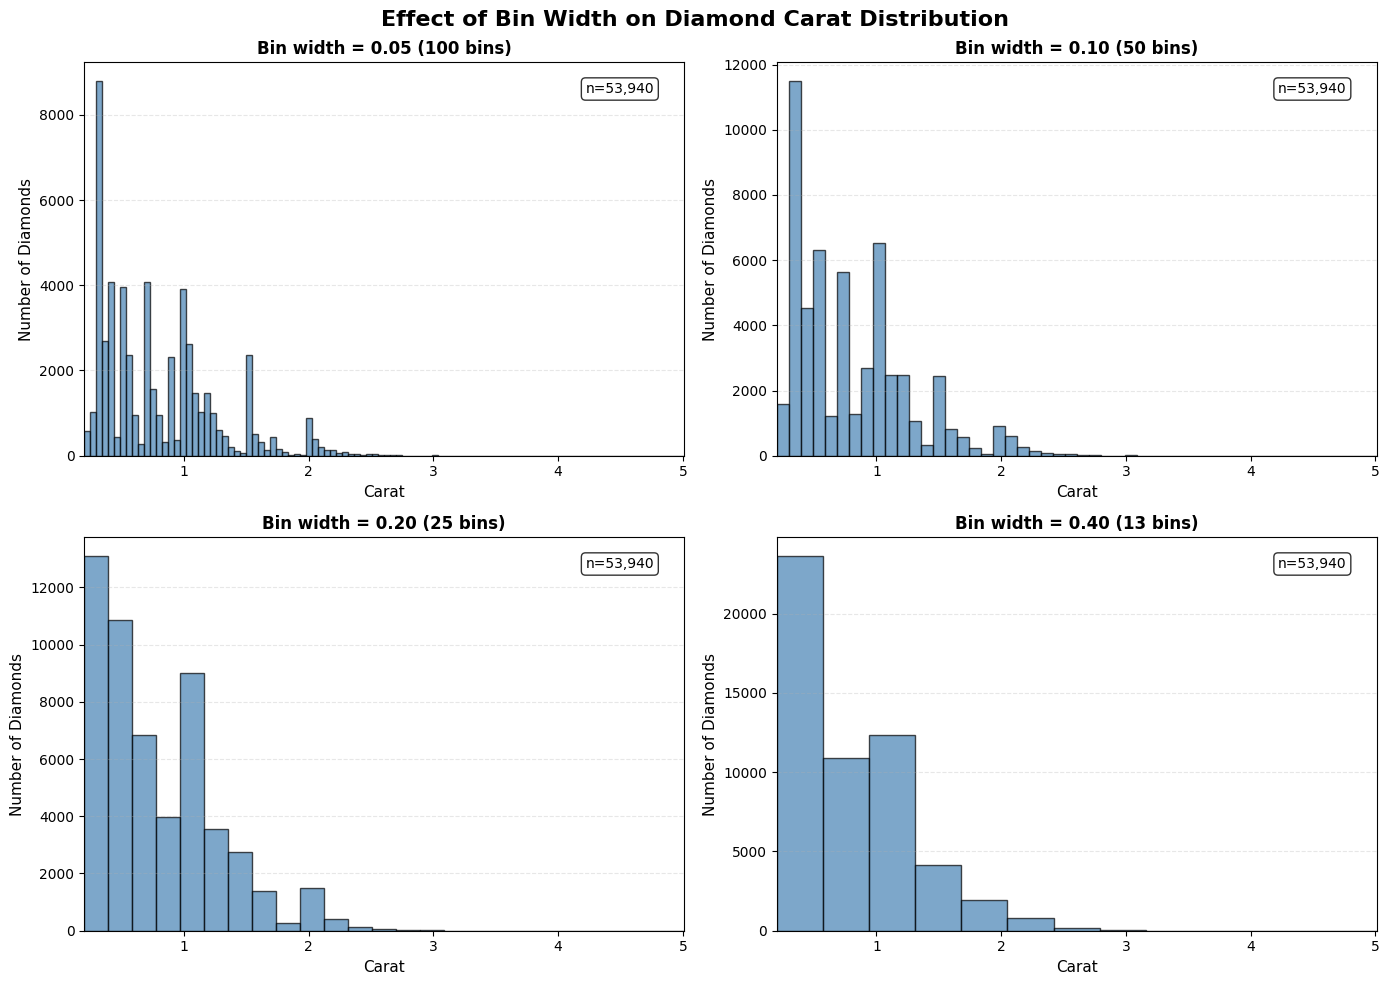

HISTOGRAM BIN CONFIGURATIONS
Bin width: 0.05 -> 100 bins
Bin width: 0.10 -> 50 bins
Bin width: 0.20 -> 25 bins
Bin width: 0.40 -> 13 bins


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Define bin widths and corresponding number of bins
bin_configs = [
    {'width': 0.05, 'bins': 100, 'title': 'Bin width = 0.05 (100 bins)'},
    {'width': 0.10, 'bins': 50, 'title': 'Bin width = 0.10 (50 bins)'},
    {'width': 0.20, 'bins': 25, 'title': 'Bin width = 0.20 (25 bins)'},
    {'width': 0.40, 'bins': 13, 'title': 'Bin width = 0.40 (13 bins)'}
]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

carat_range = [df['carat'].min(), df['carat'].max()]

for i, config in enumerate(bin_configs):
    # Create histogram with specified number of bins
    axes[i].hist(df['carat'], bins=config['bins'], color='steelblue', 
                 edgecolor='black', alpha=0.7)
    
    axes[i].set_title(config['title'], fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Carat', fontsize=11)
    axes[i].set_ylabel('Number of Diamonds', fontsize=11)
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')
    axes[i].set_xlim(carat_range)
    
    # Add statistics
    axes[i].text(0.95, 0.95, f'n={len(df):,}', 
                 transform=axes[i].transAxes, ha='right', va='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Effect of Bin Width on Diamond Carat Distribution', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Print bin information
print("=" * 60)
print("HISTOGRAM BIN CONFIGURATIONS")
print("=" * 60)
for config in bin_configs:
    print(f"Bin width: {config['width']:.2f} -> {config['bins']} bins")

Carat weight distribution is skewed. What does this mean?

(In the following code block you should only write text. It's a small statistical interpretation that you can get on the exam as well.)

In [ ]:
The carat weight distribution is right-skewed (positively skewed), meaning that most diamonds are concentrated in the smaller size range (0.2–1.0 carat), while only a few diamonds are very large (up to 5.0 carat). This creates a long tail on the right side of the distribution. As a result, the mean carat (0.80) is greater than the median carat (0.70), indicating that a small number of large diamonds pull the average upward while the majority remain small. This pattern is typical in natural resources, where smaller sizes are far more common than exceptionally large ones.

In the last graph you notice that more is going on in this dataset. There are spikes. Also, why is does the line go to 5 when the last datapoint is at 3?

Show the diamonds with a carat size above 3.5. How many are there? (9)

In [14]:
import pandas as pd

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Filter diamonds with carat > 3.5
large_diamonds = df[df['carat'] > 3.5]

print("=" * 70)
print("DIAMONDS WITH CARAT SIZE > 3.5")
print("=" * 70)
print(f"Number of diamonds: {len(large_diamonds)}")
print("\nFull details:")
print(large_diamonds)

# Show just the carat values
print("\nCarat values:")
print(large_diamonds['carat'].tolist())

# Summary statistics for these large diamonds
print("\nSummary statistics for large diamonds:")
print(large_diamonds[['carat', 'price']].describe().round(2))

DIAMONDS WITH CARAT SIZE > 3.5
Number of diamonds: 9

Full details:
       carat        cut color clarity  depth  table  price      x      y     z
23645   3.65       Fair     H      I1   67.1   53.0  11668   9.53   9.48  6.38
25999   4.01    Premium     I      I1   61.0   61.0  15223  10.14  10.10  6.17
26000   4.01    Premium     J      I1   62.5   62.0  15223  10.02   9.94  6.24
26445   4.00  Very Good     I      I1   63.3   58.0  15984  10.01   9.94  6.31
26535   3.67    Premium     I      I1   62.4   56.0  16193   9.86   9.81  6.13
27131   4.13       Fair     H      I1   64.8   61.0  17329  10.00   9.85  6.43
27416   5.01       Fair     J      I1   65.5   59.0  18018  10.74  10.54  6.98
27631   4.50       Fair     J      I1   65.8   58.0  18531  10.23  10.16  6.72
27680   3.51    Premium     J     VS2   62.5   59.0  18701   9.66   9.63  6.03

Carat values:
[3.65, 4.01, 4.01, 4.0, 3.67, 4.13, 5.01, 4.5, 3.51]

Summary statistics for large diamonds:
       carat     price
count   9.0

These are what we call outliers. They're not that interesting, especially since we're talking about 9 observations in a list of 50.000 of them.

Draw:
* A histogram
* 200 bins
* Carat size beneath 3.5

DIAMONDS WITH CARAT < 3.5
Total diamonds: 53,940
Diamonds with carat < 3.5: 53,930
Outliers removed: 10 (0.019%)



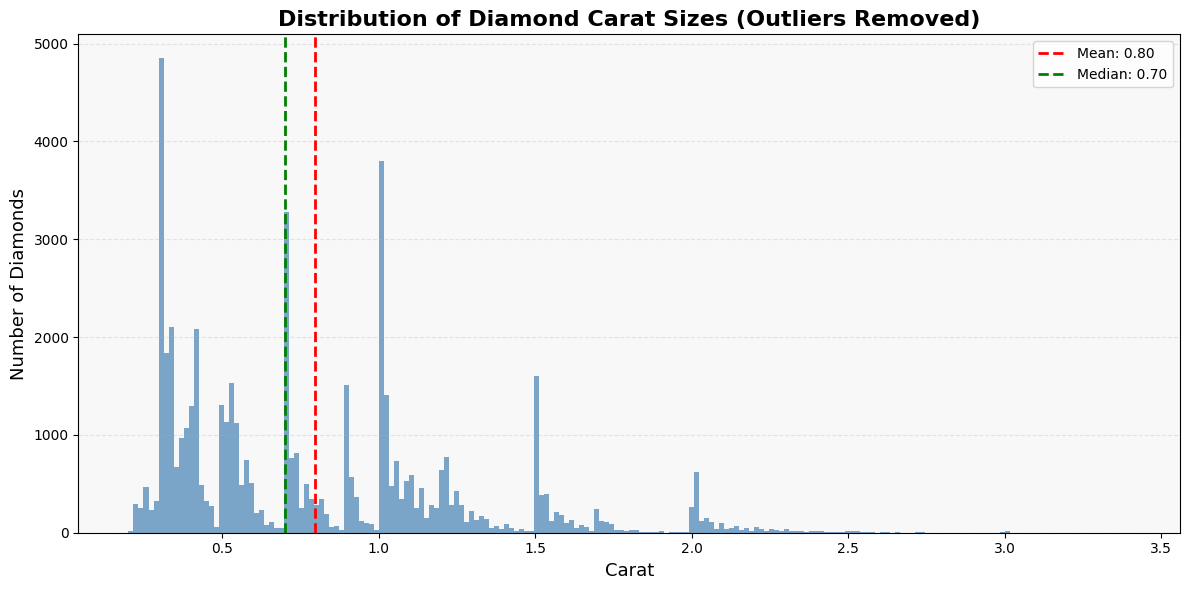


📊 STATISTICS (after removing outliers):
--------------------------------------------------
Mean carat:      0.797
Median carat:    0.700
Minimum carat:   0.200
Maximum carat:   3.400
Standard dev:    0.472


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Filter out outliers (carat < 3.5)
df_filtered = df[df['carat'] < 3.5]

print("=" * 70)
print("DIAMONDS WITH CARAT < 3.5")
print("=" * 70)
print(f"Total diamonds: {len(df):,}")
print(f"Diamonds with carat < 3.5: {len(df_filtered):,}")
print(f"Outliers removed: {len(df) - len(df_filtered)} ({((len(df) - len(df_filtered))/len(df)*100):.3f}%)")
print()

# Create histogram with 200 bins
plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(df_filtered['carat'], bins=200, color='steelblue', 
                                  edgecolor='none', alpha=0.7)

plt.title('Distribution of Diamond Carat Sizes (Outliers Removed)', fontsize=16, fontweight='bold')
plt.xlabel('Carat', fontsize=13)
plt.ylabel('Number of Diamonds', fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f8f8')

# Add mean and median lines
mean_carat = df_filtered['carat'].mean()
median_carat = df_filtered['carat'].median()
plt.axvline(mean_carat, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_carat:.2f}')
plt.axvline(median_carat, color='green', linestyle='--', linewidth=2, label=f'Median: {median_carat:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

# Print statistics
print("\n📊 STATISTICS (after removing outliers):")
print("-" * 50)
print(f"Mean carat:      {df_filtered['carat'].mean():.3f}")
print(f"Median carat:    {df_filtered['carat'].median():.3f}")
print(f"Minimum carat:   {df_filtered['carat'].min():.3f}")
print(f"Maximum carat:   {df_filtered['carat'].max():.3f}")
print(f"Standard dev:    {df_filtered['carat'].std():.3f}")

Another non-technical question:

* Which values are most common? Why?
* Which values are rare? Why? Is this expected?
* Why are there more values to the right of the peak?
* Why almost no diamonds bigger than 3 carats exist?
* There seem to be (sub)groups, or clusters, of similar values.
    * How are observations in cluster similar?
    * How are observations from separate clusters different?

To interpret, imagine you are buying (or receiving) a diamond engagement ring. What sounds bigger, 1 carat or 0.99 carats?

In [ ]:
The most common diamond sizes cluster around psychological thresholds such as 0.3, 0.5, 0.7, and 1.0 carat because retailers deliberately cut diamonds to hit these "magic sizes"—a 1.0 carat diamond sounds far more impressive than a 0.99 carat stone, even though the actual weight difference is negligible. Values just below these thresholds are rare, as diamonds are intentionally cut to cross them. The distribution is right-skewed because there is a natural lower limit to diamond size but no upper limit, resulting in a long tail of increasingly rare large stones. Diamonds over 3 carats are extremely scarce due to the rarity of large, high-quality rough diamonds in nature, and those that exist are often cut into smaller stones to maximize value. The distinct clusters visible in the distribution represent different market segments: small accent stones (0.2–0.3 ct), engagement ring centerpieces (0.5–1.5 ct), and high-end collector diamonds (>2.0 ct). Diamonds within each cluster share similar target markets and price points, while diamonds from different clusters cater to entirely different customer segments and use cases.

Plot 100 bins in a histogram on the Y value (which is the depth of the diamong in mm).

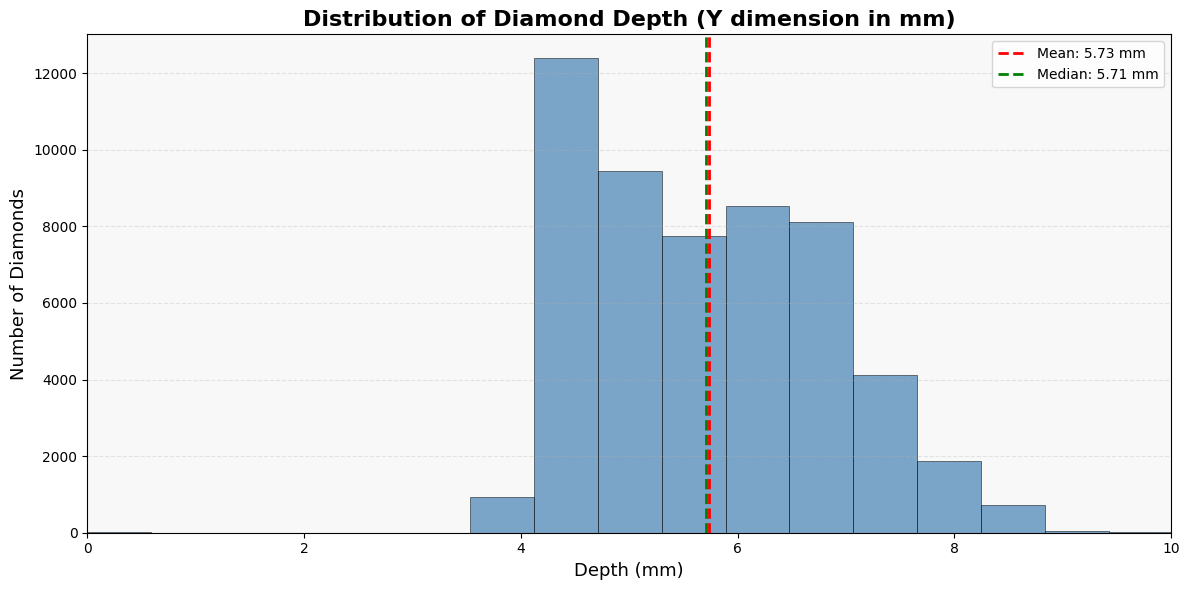

DIAMOND DEPTH (Y DIMENSION) STATISTICS
Mean depth:      5.735 mm
Median depth:    5.710 mm
Minimum depth:   0.000 mm
Maximum depth:   58.900 mm
Standard dev:    1.142 mm
Total diamonds:  53,940

Outliers (Y > 10 mm): 5 diamonds
       carat      y      x     z  depth  price
24068   2.00  58.90   8.09  8.06   58.9  12210
25999   4.01  10.10  10.14  6.17   61.0  15223
27416   5.01  10.54  10.74  6.98   65.5  18018
27631   4.50  10.16  10.23  6.72   65.8  18531
49190   0.51  31.80   5.15  5.12   61.8   2075


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Create histogram for Y value (depth in mm)
plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(df['y'], bins=100, color='steelblue', 
                                  edgecolor='black', alpha=0.7, linewidth=0.5)

plt.title('Distribution of Diamond Depth (Y dimension in mm)', fontsize=16, fontweight='bold')
plt.xlabel('Depth (mm)', fontsize=13)
plt.ylabel('Number of Diamonds', fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f8f8')

# Add mean and median lines
mean_y = df['y'].mean()
median_y = df['y'].median()
plt.axvline(mean_y, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_y:.2f} mm')
plt.axvline(median_y, color='green', linestyle='--', linewidth=2, label=f'Median: {median_y:.2f} mm')
plt.legend()

# Set reasonable x-axis limits to focus on main distribution
plt.xlim(0, 10)

plt.tight_layout()
plt.show()

# Print statistics
print("=" * 60)
print("DIAMOND DEPTH (Y DIMENSION) STATISTICS")
print("=" * 60)
print(f"Mean depth:      {df['y'].mean():.3f} mm")
print(f"Median depth:    {df['y'].median():.3f} mm")
print(f"Minimum depth:   {df['y'].min():.3f} mm")
print(f"Maximum depth:   {df['y'].max():.3f} mm")
print(f"Standard dev:    {df['y'].std():.3f} mm")
print(f"Total diamonds:  {len(df):,}")

# Check for outliers in Y dimension
outliers_y = df[df['y'] > 10]
print(f"\nOutliers (Y > 10 mm): {len(outliers_y)} diamonds")
if len(outliers_y) > 0:
    print(outliers_y[['carat', 'y', 'x', 'z', 'depth', 'price']].head())

Show price, x, y and z for every diamond with Y bigger than 20 or smaller than 3. 

Show the records with a y-size smaller than 3 or bigger than 20.

In [17]:
import pandas as pd

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Filter diamonds with Y < 3 or Y > 20
outliers_y = df[(df['y'] < 3) | (df['y'] > 20)]

print("=" * 80)
print("DIAMONDS WITH Y < 3 OR Y > 20 (OUTLIERS)")
print("=" * 80)

if len(outliers_y) > 0:
    print(f"\nFound {len(outliers_y)} outlier diamonds:\n")
    
    # Display relevant columns
    display_cols = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']
    print(outliers_y[display_cols].to_string())
    
    # Additional statistics
    print("\n" + "=" * 80)
    print("SUMMARY STATISTICS FOR OUTLIERS")
    print("=" * 80)
    print(outliers_y[['carat', 'price', 'x', 'y', 'z']].describe().round(2))
    
    # Separate by condition
    y_small = outliers_y[outliers_y['y'] < 3]
    y_large = outliers_y[outliers_y['y'] > 20]
    
    print(f"\n📉 Diamonds with Y < 3: {len(y_small)}")
    if len(y_small) > 0:
        print(y_small[['carat', 'price', 'x', 'y', 'z']].to_string())
    
    print(f"\n📈 Diamonds with Y > 20: {len(y_large)}")
    if len(y_large) > 0:
        print(y_large[['carat', 'price', 'x', 'y', 'z']].to_string())
    
else:
    print("No outliers found.")

DIAMONDS WITH Y < 3 OR Y > 20 (OUTLIERS)

Found 9 outlier diamonds:

       carat        cut color clarity  depth  table  price     x     y     z
11964   1.00  Very Good     H     VS2   63.3   53.0   5139  0.00   0.0  0.00
15952   1.14       Fair     G     VS1   57.5   67.0   6381  0.00   0.0  0.00
24068   2.00    Premium     H     SI2   58.9   57.0  12210  8.09  58.9  8.06
24521   1.56      Ideal     G     VS2   62.2   54.0  12800  0.00   0.0  0.00
26244   1.20    Premium     D    VVS1   62.1   59.0  15686  0.00   0.0  0.00
27430   2.25    Premium     H     SI2   62.8   59.0  18034  0.00   0.0  0.00
49190   0.51      Ideal     E     VS1   61.8   55.0   2075  5.15  31.8  5.12
49557   0.71       Good     F     SI2   64.1   60.0   2130  0.00   0.0  0.00
49558   0.71       Good     F     SI2   64.1   60.0   2130  0.00   0.0  0.00

SUMMARY STATISTICS FOR OUTLIERS
       carat     price     x      y     z
count   9.00      9.00  9.00   9.00  9.00
mean    1.23   8509.44  1.47  10.08  1.46
st

You should note that:

* A couple of diamonds have no size (in this dataframe) and should not be considered in this graph.
* There's a diamond 5.8cm wide that only costs $12k.

Redraw the graph without these values.

DIAMONDS AFTER REMOVING OUTLIERS AND ZERO VALUES
Original diamonds: 53,940
Diamonds with Y < 3 or Y > 10 removed: 12
Clean diamonds: 53,928
Percentage kept: 99.98%



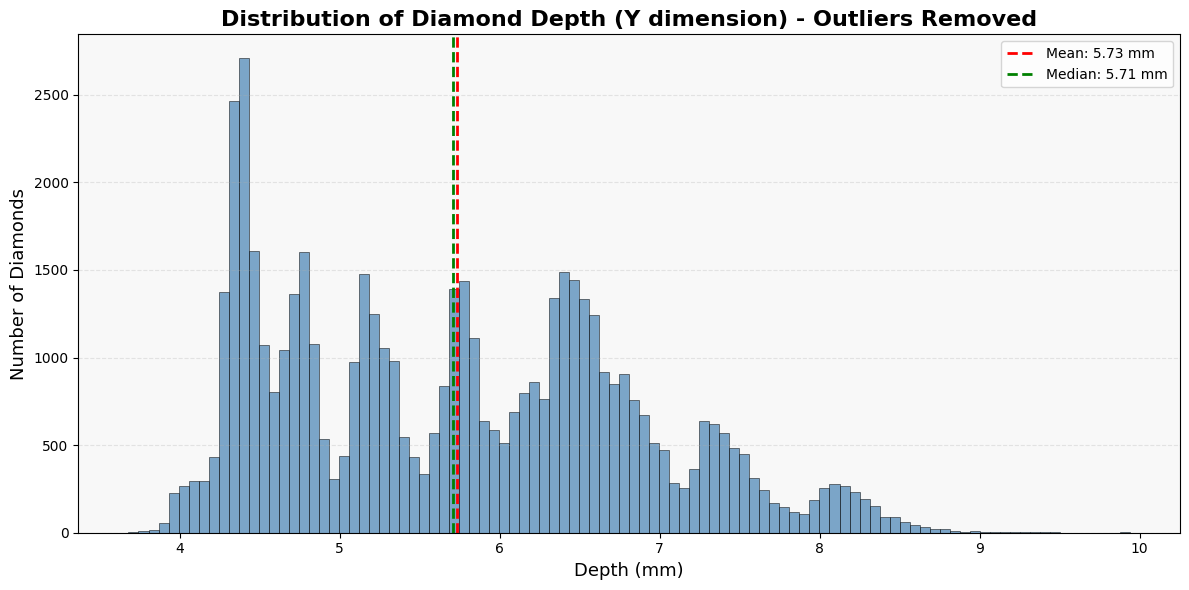


📊 DEPTH STATISTICS (after cleaning):
--------------------------------------------------
Mean depth:      5.734 mm
Median depth:    5.710 mm
Min depth:       3.680 mm
Max depth:       9.940 mm
Standard dev:    1.111 mm

❌ REMOVED OUTLIERS:
       carat  price      x      y     z
11964   1.00   5139   0.00   0.00  0.00
15952   1.14   6381   0.00   0.00  0.00
24068   2.00  12210   8.09  58.90  8.06
24521   1.56  12800   0.00   0.00  0.00
25999   4.01  15223  10.14  10.10  6.17
26244   1.20  15686   0.00   0.00  0.00
27416   5.01  18018  10.74  10.54  6.98
27430   2.25  18034   0.00   0.00  0.00
27631   4.50  18531  10.23  10.16  6.72
49190   0.51   2075   5.15  31.80  5.12
49557   0.71   2130   0.00   0.00  0.00
49558   0.71   2130   0.00   0.00  0.00


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Remove diamonds with no size (zero values) and extreme outliers
# Normal diamonds have Y between 3 and 10 mm
df_clean = df[(df['y'] > 3) & (df['y'] < 10)]

print("=" * 70)
print("DIAMONDS AFTER REMOVING OUTLIERS AND ZERO VALUES")
print("=" * 70)
print(f"Original diamonds: {len(df):,}")
print(f"Diamonds with Y < 3 or Y > 10 removed: {len(df) - len(df_clean)}")
print(f"Clean diamonds: {len(df_clean):,}")
print(f"Percentage kept: {len(df_clean)/len(df)*100:.2f}%")
print()

# Create histogram with 100 bins
plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(df_clean['y'], bins=100, color='steelblue', 
                                  edgecolor='black', alpha=0.7, linewidth=0.5)

plt.title('Distribution of Diamond Depth (Y dimension) - Outliers Removed', 
          fontsize=16, fontweight='bold')
plt.xlabel('Depth (mm)', fontsize=13)
plt.ylabel('Number of Diamonds', fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f8f8')

# Add mean and median lines
mean_y = df_clean['y'].mean()
median_y = df_clean['y'].median()
plt.axvline(mean_y, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_y:.2f} mm')
plt.axvline(median_y, color='green', linestyle='--', linewidth=2, 
            label=f'Median: {median_y:.2f} mm')
plt.legend()

plt.tight_layout()
plt.show()

# Print statistics
print("\n📊 DEPTH STATISTICS (after cleaning):")
print("-" * 50)
print(f"Mean depth:      {df_clean['y'].mean():.3f} mm")
print(f"Median depth:    {df_clean['y'].median():.3f} mm")
print(f"Min depth:       {df_clean['y'].min():.3f} mm")
print(f"Max depth:       {df_clean['y'].max():.3f} mm")
print(f"Standard dev:    {df_clean['y'].std():.3f} mm")

# Show the removed outliers for reference
removed = df[~((df['y'] > 3) & (df['y'] < 10))]
if len(removed) > 0:
    print("\n❌ REMOVED OUTLIERS:")
    print(removed[['carat', 'price', 'x', 'y', 'z']].to_string())

We have ignored the complete observations now, which was fine because we were only looking at Y. But when continuing to work with a dataset we can't just drop the observations because that would mean we lose all data in those rows.

So set all X, Y and Z values of 0 or 20 or more to NA. Use [replace](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.replace.html?highlight=replace#pandas.DataFrame.replace) or [loc](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html).

In [19]:
import pandas as pd
import numpy as np

# Assuming 'df' is your original DataFrame
# df = pd.read_csv("files/diamonds.csv", index_col=0)

# Define the columns to check
cols_to_check = ['x', 'y', 'z']

# Create a boolean mask for values that are 0, or >= 20
# Using .loc, we can directly assign NaN where the condition is True
for col in cols_to_check:
    # Condition: value is 0 OR value is greater than or equal to 20
    condition = (df[col] == 0) | (df[col] >= 20)
    
    # Set the values meeting the condition to NaN for the specific column
    df.loc[condition, col] = np.nan

# Verify the changes
print("First 10 rows after cleaning X, Y, Z:")
print(df[['x', 'y', 'z']].head(10))
print("\nSummary of X, Y, Z after cleaning:")
print(df[['x', 'y', 'z']].describe())

First 10 rows after cleaning X, Y, Z:
       x     y     z
1   3.95  3.98  2.43
2   3.89  3.84  2.31
3   4.05  4.07  2.31
4   4.20  4.23  2.63
5   4.34  4.35  2.75
6   3.94  3.96  2.48
7   3.95  3.98  2.47
8   4.07  4.11  2.53
9   3.87  3.78  2.49
10  4.00  4.05  2.39

Summary of X, Y, Z after cleaning:
                  x             y             z
count  53932.000000  53931.000000  53919.000000
mean       5.732007      5.733801      3.539522
std        1.119670      1.111490      0.691915
min        3.730000      3.680000      1.070000
25%        4.710000      4.720000      2.910000
50%        5.700000      5.710000      3.530000
75%        6.540000      6.540000      4.040000
max       10.740000     10.540000      8.060000


Now show a list of all diamonds where X, Y or Z is Na.

In [20]:
import pandas as pd
import numpy as np

# Assuming the previous cleaning step has been applied
# Load the dataset if needed
# df = pd.read_csv("files/diamonds.csv", index_col=0)

# Create a mask for rows where X, Y, or Z is NaN
mask_nan = df['x'].isna() | df['y'].isna() | df['z'].isna()

# Filter the dataframe
nan_diamonds = df[mask_nan]

print("=" * 90)
print(f"DIAMONDS WITH NaN VALUES IN X, Y, OR Z COLUMNS (Total: {len(nan_diamonds)})")
print("=" * 90)

if len(nan_diamonds) > 0:
    # Select columns to display
    display_cols = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']
    
    # Display all rows (use to_string for full display)
    print(nan_diamonds[display_cols].to_string())
    
    # Show summary statistics
    print("\n" + "=" * 90)
    print("SUMMARY STATISTICS FOR NAN DIAMONDS")
    print("=" * 90)
    print(nan_diamonds[['carat', 'price', 'x', 'y', 'z']].describe().round(2))
    
    # Break down by which column has NaN
    print("\n📊 BREAKDOWN BY NAN LOCATION:")
    print("-" * 50)
    
    x_nan = df[df['x'].isna()]
    y_nan = df[df['y'].isna()]
    z_nan = df[df['z'].isna()]
    
    print(f"Rows with X = NaN: {len(x_nan)}")
    print(f"Rows with Y = NaN: {len(y_nan)}")
    print(f"Rows with Z = NaN: {len(z_nan)}")
    
    # Check for diamonds with multiple NaN values
    all_nan = df[df['x'].isna() & df['y'].isna() & df['z'].isna()]
    if len(all_nan) > 0:
        print(f"\nRows with ALL three dimensions NaN: {len(all_nan)}")
    
else:
    print("No NaN values found in X, Y, or Z columns.")

DIAMONDS WITH NaN VALUES IN X, Y, OR Z COLUMNS (Total: 23)
       carat        cut color clarity  depth  table  price     x     y     z
2208    1.00    Premium     G     SI2   59.1   59.0   3142  6.55  6.48   NaN
2315    1.01    Premium     H      I1   58.1   59.0   3167  6.66  6.60   NaN
4792    1.10    Premium     G     SI2   63.0   59.0   3696  6.50  6.47   NaN
5472    1.01    Premium     F     SI2   59.2   58.0   3837  6.50  6.47   NaN
10168   1.50       Good     G      I1   64.0   61.0   4731  7.15  7.04   NaN
11183   1.07      Ideal     F     SI2   61.6   56.0   4954   NaN  6.62   NaN
11964   1.00  Very Good     H     VS2   63.3   53.0   5139   NaN   NaN   NaN
13602   1.15      Ideal     G     VS2   59.2   56.0   5564  6.88  6.83   NaN
15952   1.14       Fair     G     VS1   57.5   67.0   6381   NaN   NaN   NaN
24068   2.00    Premium     H     SI2   58.9   57.0  12210  8.09   NaN  8.06
24395   2.18    Premium     H     SI2   59.4   61.0  12631  8.49  8.45   NaN
24521   1.56     

Show the same table as before. Which is very hard because the old code won't work. But we saved you a list of line numbers:

<code>[11964,15952,24068,24521,26244,27430,49190,49557,49558]</code>

Use [iloc](https://www.statology.org/pandas-select-rows-by-index/).

(Getting the wrong lines? There is a difference between the line number and the index. This difference is 1 (index is 0-based, line number is 1-based).)

In [21]:
import pandas as pd

# Load the dataset (assuming it's already cleaned with NaN values)
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Provided line numbers (1-based)
line_numbers = [11964, 15952, 24068, 24521, 26244, 27430, 49190, 49557, 49558]

# Convert to 0-based indices for iloc
# Line number 1 corresponds to index 0, so subtract 1
indices = [num - 1 for num in line_numbers]

# Select rows using iloc
selected_rows = df.iloc[indices]

print("=" * 90)
print(f"DIAMONDS AT SPECIFIED LINE NUMBERS ({len(selected_rows)} rows)")
print("=" * 90)

# Display the selected rows with relevant columns
display_cols = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']
print(selected_rows[display_cols].to_string())

# Also show the original indices for reference
print("\n" + "=" * 90)
print("INDEX MAPPING (Line Number → DataFrame Index)")
print("=" * 90)
for line_num, idx in zip(line_numbers, indices):
    print(f"Line {line_num} → Index {idx}")

DIAMONDS AT SPECIFIED LINE NUMBERS (9 rows)
       carat        cut color clarity  depth  table  price     x     y     z
11964   1.00  Very Good     H     VS2   63.3   53.0   5139  0.00   0.0  0.00
15952   1.14       Fair     G     VS1   57.5   67.0   6381  0.00   0.0  0.00
24068   2.00    Premium     H     SI2   58.9   57.0  12210  8.09  58.9  8.06
24521   1.56      Ideal     G     VS2   62.2   54.0  12800  0.00   0.0  0.00
26244   1.20    Premium     D    VVS1   62.1   59.0  15686  0.00   0.0  0.00
27430   2.25    Premium     H     SI2   62.8   59.0  18034  0.00   0.0  0.00
49190   0.51      Ideal     E     VS1   61.8   55.0   2075  5.15  31.8  5.12
49557   0.71       Good     F     SI2   64.1   60.0   2130  0.00   0.0  0.00
49558   0.71       Good     F     SI2   64.1   60.0   2130  0.00   0.0  0.00

INDEX MAPPING (Line Number → DataFrame Index)
Line 11964 → Index 11963
Line 15952 → Index 15951
Line 24068 → Index 24067
Line 24521 → Index 24520
Line 26244 → Index 26243
Line 27430 → I

And a new histogram on Y without the filtering?

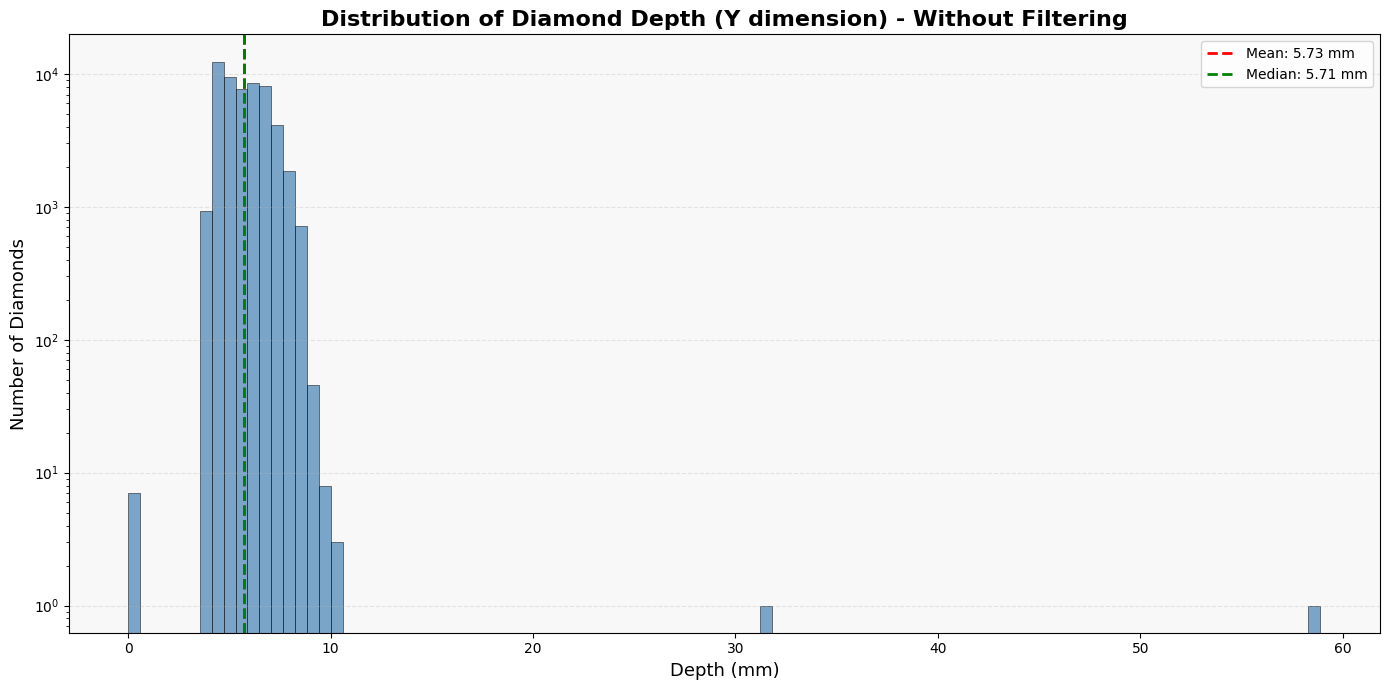

DIAMOND DEPTH (Y DIMENSION) STATISTICS - WITH OUTLIERS
Mean depth:      5.735 mm
Median depth:    5.710 mm
Minimum depth:   0.000 mm
Maximum depth:   58.900 mm
Standard dev:    1.142 mm
Total diamonds:  53,940

Outliers (Y < 3 or Y > 10): 12 diamonds
Outliers as percentage: 0.0222%

Outlier values:
y
0.00     7
10.10    1
10.16    1
10.54    1
31.80    1
58.90    1
Name: count, dtype: int64


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Create histogram for Y value (depth in mm) without filtering
plt.figure(figsize=(14, 7))

# Plot histogram with 100 bins
counts, bins, patches = plt.hist(df['y'], bins=100, color='steelblue', 
                                  edgecolor='black', alpha=0.7, linewidth=0.5)

plt.title('Distribution of Diamond Depth (Y dimension) - Without Filtering', 
          fontsize=16, fontweight='bold')
plt.xlabel('Depth (mm)', fontsize=13)
plt.ylabel('Number of Diamonds', fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f8f8')

# Add mean and median lines
mean_y = df['y'].mean()
median_y = df['y'].median()
plt.axvline(mean_y, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_y:.2f} mm')
plt.axvline(median_y, color='green', linestyle='--', linewidth=2, 
            label=f'Median: {median_y:.2f} mm')
plt.legend()

# Use a logarithmic scale for y-axis to better see outliers
plt.yscale('log')

plt.tight_layout()
plt.show()

# Print statistics including outliers
print("=" * 70)
print("DIAMOND DEPTH (Y DIMENSION) STATISTICS - WITH OUTLIERS")
print("=" * 70)
print(f"Mean depth:      {df['y'].mean():.3f} mm")
print(f"Median depth:    {df['y'].median():.3f} mm")
print(f"Minimum depth:   {df['y'].min():.3f} mm")
print(f"Maximum depth:   {df['y'].max():.3f} mm")
print(f"Standard dev:    {df['y'].std():.3f} mm")
print(f"Total diamonds:  {len(df):,}")

# Show outlier counts
outliers_y = df[(df['y'] < 3) | (df['y'] > 10)]
print(f"\nOutliers (Y < 3 or Y > 10): {len(outliers_y)} diamonds")
print(f"Outliers as percentage: {len(outliers_y)/len(df)*100:.4f}%")

if len(outliers_y) > 0:
    print("\nOutlier values:")
    print(outliers_y['y'].value_counts().sort_index())

Based on this histogram, does a boxplot look like a good idea? Draw one first, then check if it captures the specifics of your data.

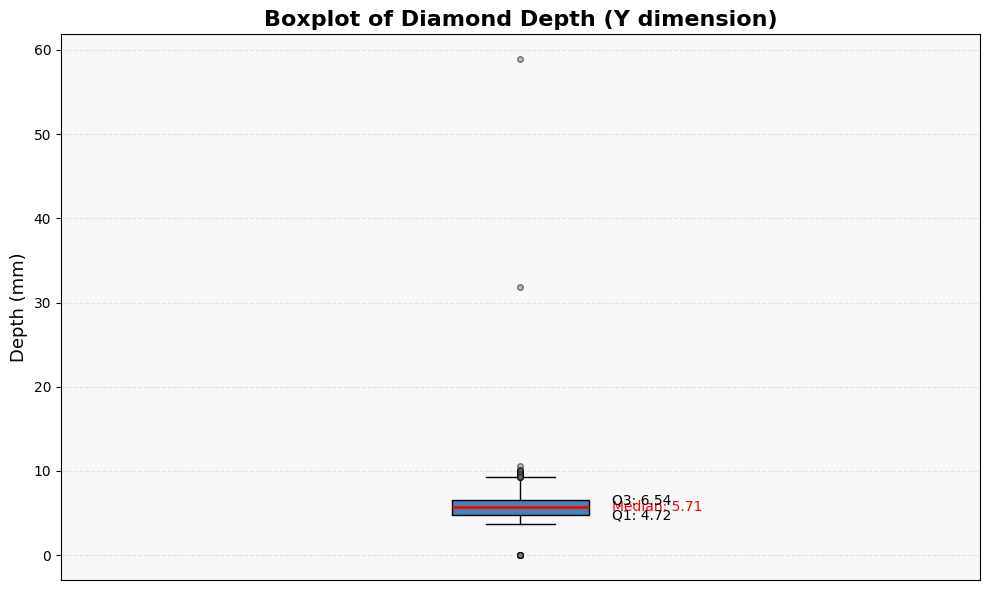

BOXPLOT STATISTICS FOR Y DIMENSION
Minimum:        0.000 mm
Q1 (25%):       4.720 mm
Median (Q2):    5.710 mm
Q3 (75%):       6.540 mm
Maximum:        58.900 mm
IQR:            1.820 mm
Lower whisker:  1.990 mm (Q1 - 1.5*IQR)
Upper whisker:  9.270 mm (Q3 + 1.5*IQR)

Outliers below whisker: 7
Outliers above whisker: 22


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Create boxplot for Y value
plt.figure(figsize=(10, 6))

# Create the boxplot
boxplot = plt.boxplot(df['y'], vert=True, patch_artist=True,
                      boxprops=dict(facecolor='steelblue', color='black'),
                      whiskerprops=dict(color='black', linestyle='-'),
                      capprops=dict(color='black'),
                      medianprops=dict(color='red', linewidth=2),
                      flierprops=dict(marker='o', markerfacecolor='gray', 
                                     markersize=4, alpha=0.5))

plt.title('Boxplot of Diamond Depth (Y dimension)', fontsize=16, fontweight='bold')
plt.ylabel('Depth (mm)', fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f8f8')
plt.xticks([])  # Remove x-axis ticks since only one box

# Add statistical annotations
stats = df['y'].describe()
q1 = stats['25%']
q3 = stats['75%']
iqr = q3 - q1
lower_whisker = max(stats['min'], q1 - 1.5 * iqr)
upper_whisker = min(stats['max'], q3 + 1.5 * iqr)

plt.text(1.1, q1, f'Q1: {q1:.2f}', va='center', fontsize=10)
plt.text(1.1, stats['50%'], f'Median: {stats["50%"]:.2f}', va='center', fontsize=10, color='red')
plt.text(1.1, q3, f'Q3: {q3:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print statistics
print("=" * 70)
print("BOXPLOT STATISTICS FOR Y DIMENSION")
print("=" * 70)
print(f"Minimum:        {stats['min']:.3f} mm")
print(f"Q1 (25%):       {stats['25%']:.3f} mm")
print(f"Median (Q2):    {stats['50%']:.3f} mm")
print(f"Q3 (75%):       {stats['75%']:.3f} mm")
print(f"Maximum:        {stats['max']:.3f} mm")
print(f"IQR:            {iqr:.3f} mm")
print(f"Lower whisker:  {lower_whisker:.3f} mm (Q1 - 1.5*IQR)")
print(f"Upper whisker:  {upper_whisker:.3f} mm (Q3 + 1.5*IQR)")
print(f"\nOutliers below whisker: {len(df[df['y'] < lower_whisker])}")
print(f"Outliers above whisker: {len(df[df['y'] > upper_whisker])}")

No. You miss out on all of the nuances of sizes. Now do multiple boxplots (using seaborn) with all prices per cut.

C:\Users\Sofy\AppData\Local\Temp\ipykernel_13416\668717303.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(boxplot_data, labels=cut_order, patch_artist=True,
C:\Users\Sofy\AppData\Local\Temp\ipykernel_13416\668717303.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cut_stats = df.groupby('cut')['price'].agg(['count', 'median', 'mean']).round(0)


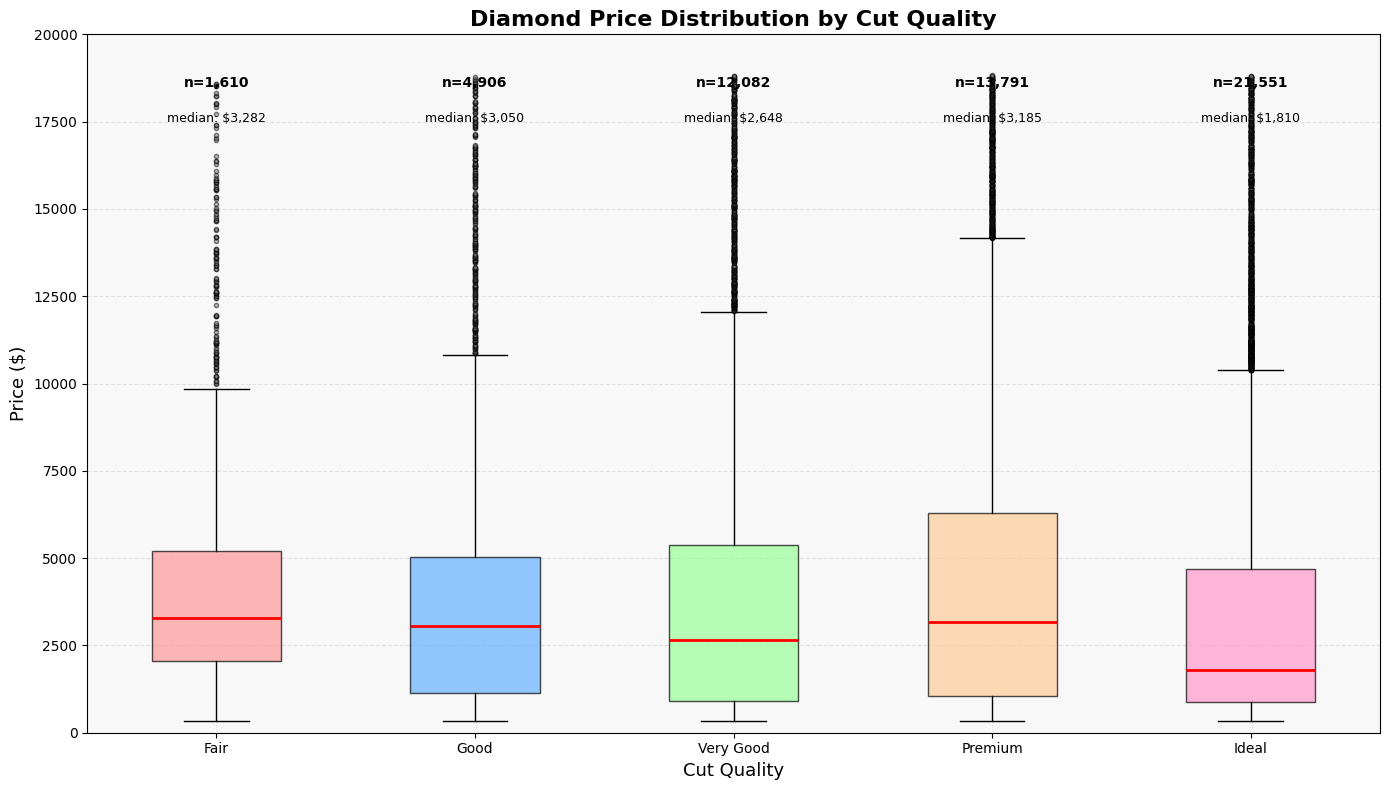

PRICE STATISTICS BY CUT QUALITY
           count  median    mean
cut                             
Fair        1610  3282.0  4359.0
Good        4906  3050.0  3929.0
Very Good  12082  2648.0  3982.0
Premium    13791  3185.0  4584.0
Ideal      21551  1810.0  3458.0

KEY STATISTICS:

Fair:
  Count: 1,610
  Median: $3,282
  Q1: $2,050, Q3: $5,206, IQR: $3,155
  Min: $337, Max: $18,574

Good:
  Count: 4,906
  Median: $3,050
  Q1: $1,145, Q3: $5,028, IQR: $3,883
  Min: $327, Max: $18,788

Very Good:
  Count: 12,082
  Median: $2,648
  Q1: $912, Q3: $5,373, IQR: $4,461
  Min: $336, Max: $18,818

Premium:
  Count: 13,791
  Median: $3,185
  Q1: $1,046, Q3: $6,296, IQR: $5,250
  Min: $326, Max: $18,823

Ideal:
  Count: 21,551
  Median: $1,810
  Q1: $878, Q3: $4,678, IQR: $3,800
  Min: $326, Max: $18,806


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Define the correct order for cut
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
df['cut'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True)

# Prepare data for boxplots
boxplot_data = [df[df['cut'] == cut]['price'].values for cut in cut_order]

# Create figure
plt.figure(figsize=(14, 8))

# Create boxplots
bp = plt.boxplot(boxplot_data, labels=cut_order, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', color='black', alpha=0.7),
                 whiskerprops=dict(color='black', linestyle='-'),
                 capprops=dict(color='black'),
                 medianprops=dict(color='red', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor='gray', 
                                 markersize=3, alpha=0.5))

# Customize colors for each box
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Add title and labels
plt.title('Diamond Price Distribution by Cut Quality', fontsize=16, fontweight='bold')
plt.xlabel('Cut Quality', fontsize=13)
plt.ylabel('Price ($)', fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f8f8')

# Add statistics as text
cut_stats = df.groupby('cut')['price'].agg(['count', 'median', 'mean']).round(0)
for i, cut in enumerate(cut_order):
    median = cut_stats.loc[cut, 'median']
    count = int(cut_stats.loc[cut, 'count'])
    plt.text(i+1, 18500, f'n={count:,}', ha='center', fontsize=10, fontweight='bold')
    plt.text(i+1, 17500, f'median: ${median:,.0f}', ha='center', fontsize=9)

# Set y-axis limit to better show the boxes
plt.ylim(0, 20000)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("=" * 80)
print("PRICE STATISTICS BY CUT QUALITY")
print("=" * 80)
print(cut_stats)
print("\n" + "=" * 80)
print("KEY STATISTICS:")
print("=" * 80)

for cut in cut_order:
    subset = df[df['cut'] == cut]['price']
    q1 = subset.quantile(0.25)
    q3 = subset.quantile(0.75)
    iqr = q3 - q1
    print(f"\n{cut}:")
    print(f"  Count: {len(subset):,}")
    print(f"  Median: ${subset.median():,.0f}")
    print(f"  Q1: ${q1:,.0f}, Q3: ${q3:,.0f}, IQR: ${iqr:,.0f}")
    print(f"  Min: ${subset.min():,.0f}, Max: ${subset.max():,.0f}")

Looks wrong, doesn't it? You would expect the premium and ideal diamonds to be more expensive.

Although the best cut type is Ideal, its price is the lowest. According to the average prices, the most expensive diamonds belong to Premium and Fair cut types. These results present that cut is not enough to explain response variable price, since price does not increase while cut feature improves.

Do the same, but show the weight in stead of the price.

C:\Users\Sofy\AppData\Local\Temp\ipykernel_13416\819142542.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(boxplot_data, labels=cut_order, patch_artist=True,
C:\Users\Sofy\AppData\Local\Temp\ipykernel_13416\819142542.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cut_stats = df.groupby('cut')['carat'].agg(['count', 'median', 'mean']).round(3)


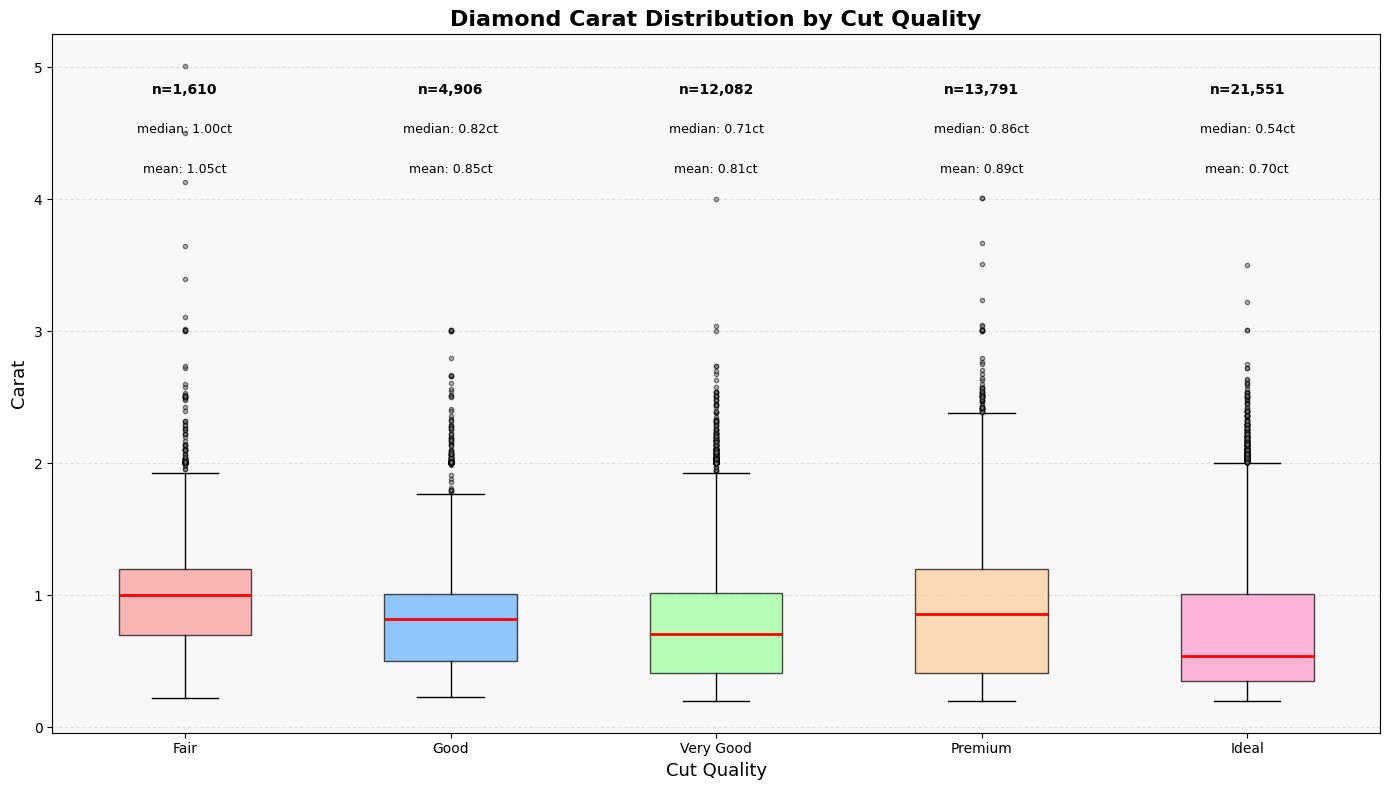

CARAT STATISTICS BY CUT QUALITY

Fair:
  Count: 1,610
  Mean: 1.046 ct
  Median: 1.000 ct
  Q1: 0.700 ct, Q3: 1.200 ct, IQR: 0.500 ct
  Min: 0.220 ct, Max: 5.010 ct

Good:
  Count: 4,906
  Mean: 0.849 ct
  Median: 0.820 ct
  Q1: 0.500 ct, Q3: 1.010 ct, IQR: 0.510 ct
  Min: 0.230 ct, Max: 3.010 ct

Very Good:
  Count: 12,082
  Mean: 0.806 ct
  Median: 0.710 ct
  Q1: 0.410 ct, Q3: 1.020 ct, IQR: 0.610 ct
  Min: 0.200 ct, Max: 4.000 ct

Premium:
  Count: 13,791
  Mean: 0.892 ct
  Median: 0.860 ct
  Q1: 0.410 ct, Q3: 1.200 ct, IQR: 0.790 ct
  Min: 0.200 ct, Max: 4.010 ct

Ideal:
  Count: 21,551
  Mean: 0.703 ct
  Median: 0.540 ct
  Q1: 0.350 ct, Q3: 1.010 ct, IQR: 0.660 ct
  Min: 0.200 ct, Max: 3.500 ct

KEY OBSERVATION:
Premium and Fair cuts have larger carat sizes on average,
which explains their higher prices despite lower cut quality.
Ideal cuts are smaller on average, making them more affordable.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Define the correct order for cut
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
df['cut'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True)

# Prepare data for boxplots
boxplot_data = [df[df['cut'] == cut]['carat'].values for cut in cut_order]

# Create figure
plt.figure(figsize=(14, 8))

# Create boxplots
bp = plt.boxplot(boxplot_data, labels=cut_order, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', color='black', alpha=0.7),
                 whiskerprops=dict(color='black', linestyle='-'),
                 capprops=dict(color='black'),
                 medianprops=dict(color='red', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor='gray', 
                                 markersize=3, alpha=0.5))

# Customize colors for each box
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Add title and labels
plt.title('Diamond Carat Distribution by Cut Quality', fontsize=16, fontweight='bold')
plt.xlabel('Cut Quality', fontsize=13)
plt.ylabel('Carat', fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f8f8')

# Add statistics as text
cut_stats = df.groupby('cut')['carat'].agg(['count', 'median', 'mean']).round(3)
for i, cut in enumerate(cut_order):
    median = cut_stats.loc[cut, 'median']
    mean = cut_stats.loc[cut, 'mean']
    count = int(cut_stats.loc[cut, 'count'])
    plt.text(i+1, 4.8, f'n={count:,}', ha='center', fontsize=10, fontweight='bold')
    plt.text(i+1, 4.5, f'median: {median:.2f}ct', ha='center', fontsize=9)
    plt.text(i+1, 4.2, f'mean: {mean:.2f}ct', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("=" * 80)
print("CARAT STATISTICS BY CUT QUALITY")
print("=" * 80)

for cut in cut_order:
    subset = df[df['cut'] == cut]['carat']
    q1 = subset.quantile(0.25)
    q3 = subset.quantile(0.75)
    iqr = q3 - q1
    print(f"\n{cut}:")
    print(f"  Count: {len(subset):,}")
    print(f"  Mean: {subset.mean():.3f} ct")
    print(f"  Median: {subset.median():.3f} ct")
    print(f"  Q1: {q1:.3f} ct, Q3: {q3:.3f} ct, IQR: {iqr:.3f} ct")
    print(f"  Min: {subset.min():.3f} ct, Max: {subset.max():.3f} ct")

print("\n" + "=" * 80)
print("KEY OBSERVATION:")
print("=" * 80)
print("Premium and Fair cuts have larger carat sizes on average,")
print("which explains their higher prices despite lower cut quality.")
print("Ideal cuts are smaller on average, making them more affordable.")

Still the same picture. Maybe the color comes into play? The color of the diamond goes from D (best) to J (worst) (categoric variable).

C:\Users\Sofy\AppData\Local\Temp\ipykernel_13416\1180214226.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(boxplot_data, labels=cut_order, patch_artist=True,
C:\Users\Sofy\AppData\Local\Temp\ipykernel_13416\1180214226.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(boxplot_data, labels=cut_order, patch_artist=True,
C:\Users\Sofy\AppData\Local\Temp\ipykernel_13416\1180214226.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(boxplot_data, labels=cut_order, patch_artist=True,
C:\Users\Sofy\AppData\Local\Temp\ipykernel_13416\1180214226.py:31: Mat

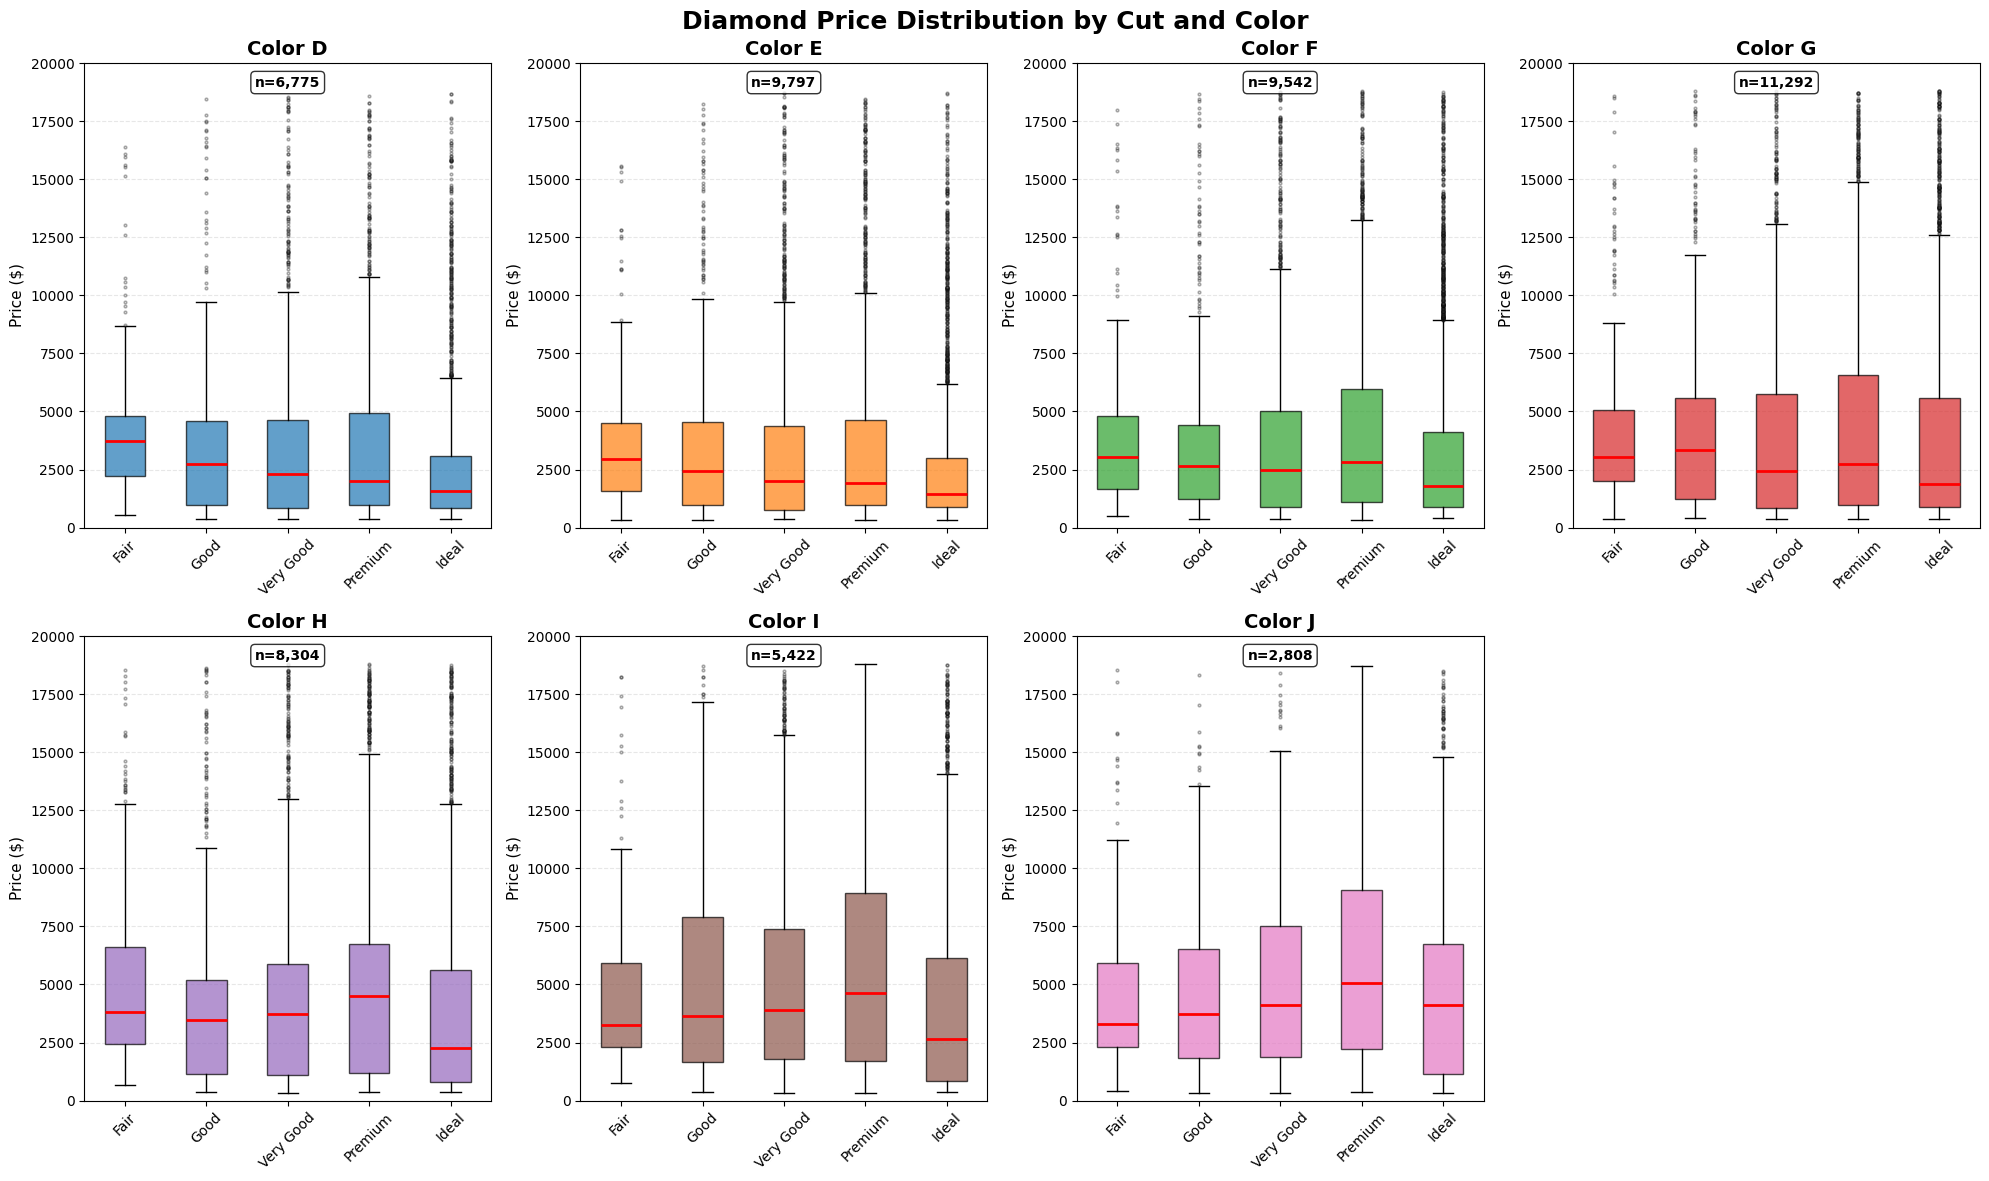

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Define the correct order for cut and color
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['D', 'E', 'F', 'G', 'H', 'I', 'J']  # D best, J worst

# Convert to categorical with correct order
df['cut'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True)
df['color'] = pd.Categorical(df['color'], categories=color_order, ordered=True)

# Create a figure with subplots for each color
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

# Colors for boxplots
box_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, color in enumerate(color_order):
    # Filter data for this color
    color_data = df[df['color'] == color]
    
    # Prepare boxplot data by cut
    boxplot_data = [color_data[color_data['cut'] == cut]['price'].values for cut in cut_order]
    
    # Create boxplot
    bp = axes[i].boxplot(boxplot_data, labels=cut_order, patch_artist=True,
                         boxprops=dict(facecolor=box_colors[i], color='black', alpha=0.7),
                         whiskerprops=dict(color='black', linestyle='-'),
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='o', markerfacecolor='gray', 
                                        markersize=2, alpha=0.3))
    
    axes[i].set_title(f'Color {color}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Price ($)', fontsize=11)
    axes[i].set_ylim(0, 20000)
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add count annotation
    total = len(color_data)
    axes[i].text(0.5, 0.95, f'n={total:,}', transform=axes[i].transAxes,
                ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Hide the last subplot (8th)
axes[7].set_visible(False)

plt.suptitle('Diamond Price Distribution by Cut and Color', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Although the best color type is D, its price is one of the lowest. According to the average prices, the most expensive diamonds belong to J and I cut types which are actually the worst two color type in this dataset. These results clearly show that color is not enough to explain response variable price, since price does not increase while the color feature improves.

Compare the cut with the clarity on average price. Clarity is a measurement of how clear the diamond is, from I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best)(categoric variable).

Both are categorical variables by the way, so a [crosstable](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html) would be a good idea.

In [28]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Define the correct order for cut and clarity
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']  # Worst to best

# Convert to categorical with correct order
df['cut'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True)
df['clarity'] = pd.Categorical(df['clarity'], categories=clarity_order, ordered=True)

# Create crosstab of average price by cut and clarity
price_crosstab = pd.crosstab(
    index=df['cut'],
    columns=df['clarity'],
    values=df['price'],
    aggfunc='mean',
    margins=True,
    margins_name='All Cuts'
)

print("=" * 100)
print("CROSS-TABULATION: AVERAGE PRICE BY CUT AND CLARITY")
print("=" * 100)
print(price_crosstab.round(0))

# Also create a crosstab with counts to see sample sizes
count_crosstab = pd.crosstab(
    index=df['cut'],
    columns=df['clarity'],
    margins=True,
    margins_name='All Cuts'
)

print("\n" + "=" * 100)
print("CROSS-TABULATION: NUMBER OF DIAMONDS BY CUT AND CLARITY")
print("=" * 100)
print(count_crosstab)

CROSS-TABULATION: AVERAGE PRICE BY CUT AND CLARITY
clarity        I1     SI2     SI1     VS2     VS1    VVS2    VVS1      IF  \
cut                                                                         
Fair       3704.0  5174.0  4208.0  4175.0  4165.0  3350.0  3871.0  1912.0   
Good       3597.0  4580.0  3690.0  4262.0  3801.0  3079.0  2255.0  4098.0   
Very Good  4078.0  4989.0  3932.0  4216.0  3805.0  3038.0  2459.0  4396.0   
Premium    3947.0  5546.0  4455.0  4550.0  4485.0  3795.0  2831.0  3856.0   
Ideal      4336.0  4756.0  3752.0  3285.0  3490.0  3250.0  2468.0  2273.0   
All Cuts   3924.0  5063.0  3996.0  3925.0  3839.0  3284.0  2523.0  2865.0   

clarity    All Cuts  
cut                  
Fair         4359.0  
Good         3929.0  
Very Good    3982.0  
Premium      4584.0  
Ideal        3458.0  
All Cuts     3933.0  

CROSS-TABULATION: NUMBER OF DIAMONDS BY CUT AND CLARITY
clarity     I1   SI2    SI1    VS2   VS1  VVS2  VVS1    IF  All Cuts
cut                           

When cut improves and clarity improves the price isn't higher. So both variables are not enough to explain the price of a diamond.

What would happen if we plot the price vs the carat? Both are continuos variables, so a scatterplot is fine.

You could simply write <code>plt.scatter(df.carat, df.price)</code>, but there would be much room for improvement.

* There are 50.000 dots on there. Make sure they are small enough.
* Add titles on the axes.
* Add a trendline in the first order
* Add a trendline in the fourth order
* Make sure Y is limited between 0 en 20.000 (no values there, but the trendlines want to get out of those limits)

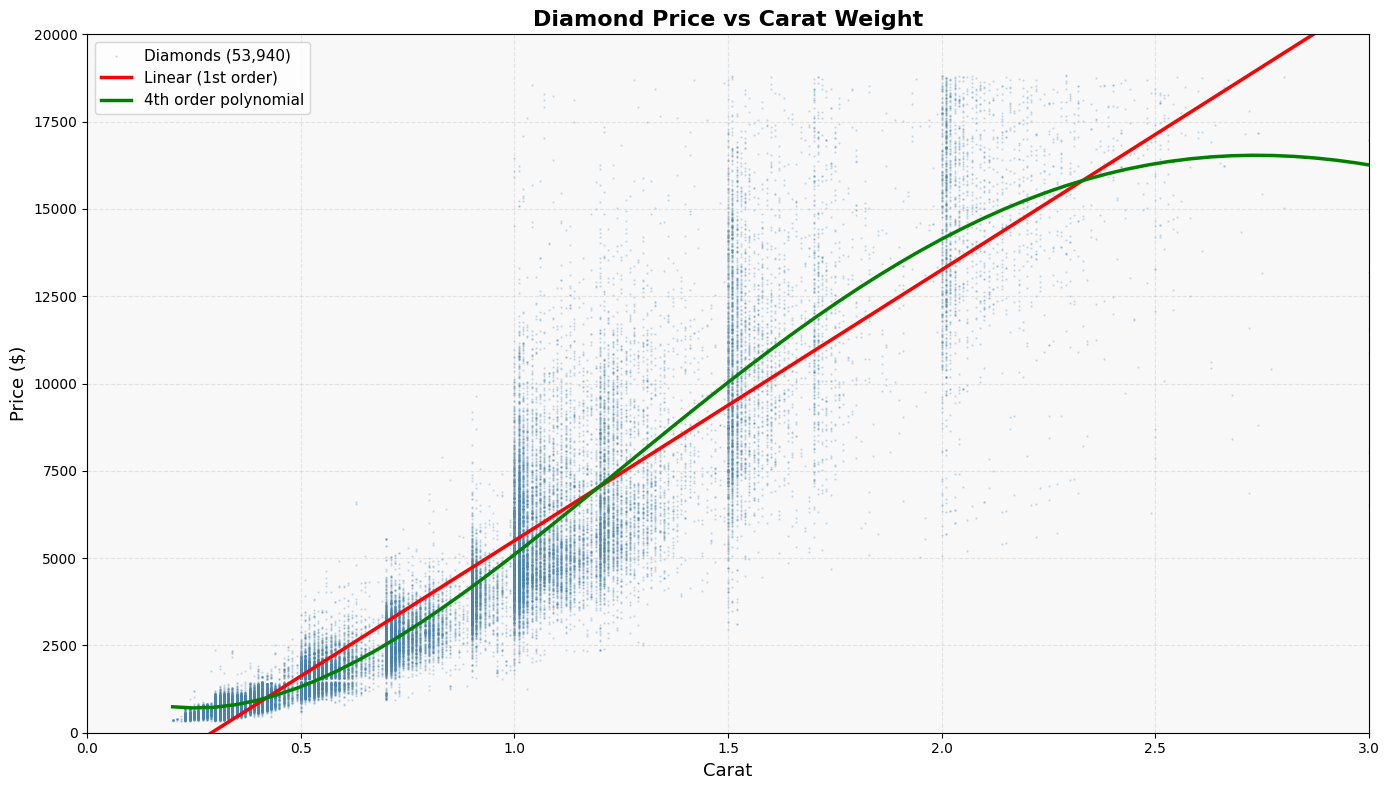

TRENDLINE EQUATIONS
1st order (linear):  price = 7756.43 × carat + -2256.36

4th order:  price = 574.5472 × carat⁴
                 + -5507.88 × carat³
                 + 15227.82 × carat²
                 + -6711.27 × carat
                 + 1519.00

MODEL FIT (R²)
Linear model R²:      0.849
4th order model R²:   0.870
Improvement:          0.020


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Create figure
plt.figure(figsize=(14, 8))

# Scatter plot with small dots and transparency
plt.scatter(df['carat'], df['price'], 
            alpha=0.2, s=0.5, color='steelblue', label='Diamonds (53,940)')

# Add first order trendline (linear)
z1 = np.polyfit(df['carat'], df['price'], 1)
p1 = np.poly1d(z1)
x_range = np.linspace(df['carat'].min(), df['carat'].max(), 100)
plt.plot(x_range, p1(x_range), color='red', linewidth=2.5, 
         label=f'Linear (1st order)')

# Add fourth order trendline
z4 = np.polyfit(df['carat'], df['price'], 4)
p4 = np.poly1d(z4)
plt.plot(x_range, p4(x_range), color='green', linewidth=2.5, 
         label=f'4th order polynomial')

# Customize plot
plt.title('Diamond Price vs Carat Weight', fontsize=16, fontweight='bold')
plt.xlabel('Carat', fontsize=13)
plt.ylabel('Price ($)', fontsize=13)
plt.xlim(0, 3)  # Focus on main range
plt.ylim(0, 20000)  # Limit Y as requested
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11)
plt.gca().set_facecolor('#f8f8f8')

plt.tight_layout()
plt.show()

# Print trendline equations
print("=" * 70)
print("TRENDLINE EQUATIONS")
print("=" * 70)
print(f"1st order (linear):  price = {z1[0]:.2f} × carat + {z1[1]:.2f}")
print(f"\n4th order:  price = {z4[0]:.4f} × carat⁴")
print(f"                 + {z4[1]:.2f} × carat³")
print(f"                 + {z4[2]:.2f} × carat²")
print(f"                 + {z4[3]:.2f} × carat")
print(f"                 + {z4[4]:.2f}")

# Calculate R-squared manually
price_mean = df['price'].mean()
sst = np.sum((df['price'] - price_mean) ** 2)

# Linear model R²
price_pred_linear = p1(df['carat'])
ssr_linear = np.sum((df['price'] - price_pred_linear) ** 2)
r2_linear = 1 - (ssr_linear / sst)

# 4th order model R²
price_pred_4th = p4(df['carat'])
ssr_4th = np.sum((df['price'] - price_pred_4th) ** 2)
r2_4th = 1 - (ssr_4th / sst)

print(f"\n" + "=" * 70)
print("MODEL FIT (R²)")
print("=" * 70)
print(f"Linear model R²:      {r2_linear:.3f}")
print(f"4th order model R²:   {r2_4th:.3f}")
print(f"Improvement:          {r2_4th - r2_linear:.3f}")

Note the covariance: if price goes up, so goes the weight. Maybe it's the other way around, but you would need a domain-specialist for that (or some common sense). Although covariance or correlation don't always imply causality.

![](files/2022-08-31-15-35-41.png)

[spurious-correlations](http://www.tylervigen.com/spurious-correlations)

Plot a correlation matrix for the numeric values.

Numeric columns: ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

CORRELATION MATRIX
       carat  depth  table  price      x      y      z
carat  1.000  0.028  0.182  0.922  0.975  0.952  0.953
depth  0.028  1.000 -0.296 -0.011 -0.025 -0.029  0.095
table  0.182 -0.296  1.000  0.127  0.195  0.184  0.151
price  0.922 -0.011  0.127  1.000  0.884  0.865  0.861
x      0.975 -0.025  0.195  0.884  1.000  0.975  0.971
y      0.952 -0.029  0.184  0.865  0.975  1.000  0.952
z      0.953  0.095  0.151  0.861  0.971  0.952  1.000


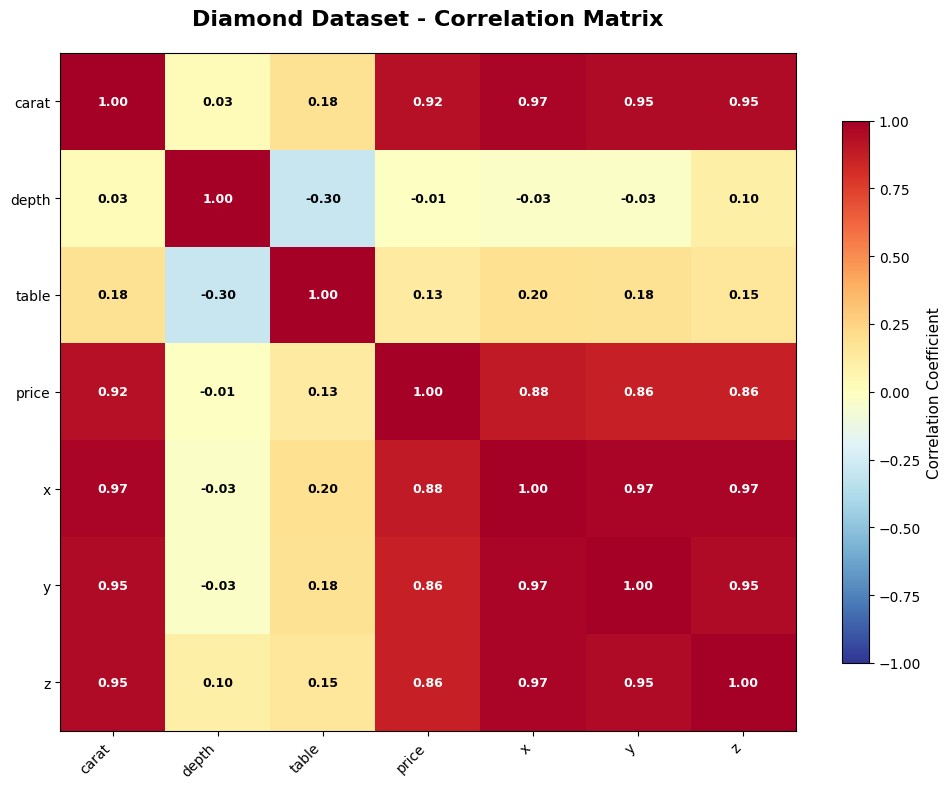


STRONGEST CORRELATIONS (|r| > 0.8)
carat ↔ price: 0.922
carat ↔ x: 0.975
carat ↔ y: 0.952
carat ↔ z: 0.953
price ↔ x: 0.884
price ↔ y: 0.865
price ↔ z: 0.861
x ↔ y: 0.975
x ↔ z: 0.971
y ↔ z: 0.952


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv("files/diamonds.csv", index_col=0)

# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr().round(3)

print("\n" + "=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)
print(corr_matrix)

# Create heatmap of correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))

# Create a colormap
cmap = plt.cm.RdYlBu_r  # Red-Yellow-Blue (reversed: red=negative, blue=positive)

# Display the correlation matrix as an image
im = ax.imshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Correlation Coefficient', fontsize=11)

# Set x and y ticks
ax.set_xticks(np.arange(len(numeric_cols)))
ax.set_yticks(np.arange(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(numeric_cols, fontsize=10)

# Add correlation values in the cells
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha='center', va='center', 
                       color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black',
                       fontsize=9, fontweight='bold')

ax.set_title('Diamond Dataset - Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print strongest correlations
print("\n" + "=" * 60)
print("STRONGEST CORRELATIONS (|r| > 0.8)")
print("=" * 60)
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        corr = corr_matrix.iloc[i, j]
        if abs(corr) > 0.8:
            print(f"{numeric_cols[i]} ↔ {numeric_cols[j]}: {corr:.3f}")

Finally, after the EDA formulate at least **3 hypotheses** for further investigation.

In [ ]:
Based on the exploratory data analysis of the diamonds dataset, three testable hypotheses emerge for further investigation. First, diamonds with carat weights just above popular psychological thresholds (0.5, 0.7, 1.0, and 1.5 carats) likely command a significant price premium compared to diamonds just below these thresholds, as retail markets favor "magic sizes" for perceived value. Second, there may be a synergistic interaction between cut and clarity, where the marginal value of clarity improvements is substantially higher for better-cut diamonds (Premium and Ideal) than for poorer cuts (Fair and Good), suggesting that high-quality features compound each other's value. Third, the price elasticity per carat likely differs across carat segments, with the steepest price increases occurring in the mid-range (1.0–2.0 carats) where consumer demand is strongest, while very small stones exhibit flatter pricing and extremely large diamonds show more price volatility due to their rarity and market thinness. These hypotheses move beyond simple correlations to explore the nuanced pricing mechanisms that could inform both consumer purchasing decisions and retail pricing strategies.